[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/notebooks/EN/chapter7_lecture_notebook.ipynb)

# Statistics of Financial Markets — Chapter 7: Efficient markets, random walk and variance-ratio tests

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- Can past prices predict returns? Today's return against yesterday's; random walks against the S&P 500.
- White noise and the autocorrelation function (SFEtimewn, SFEacfar1, SFEacfar2, SFEacfma1, SFEacfma2).
- Box–Pierce, Ljung–Box and robust portmanteau tests; the runs test.
- Unit roots: ADF, Phillips–Perron and KPSS on log prices and returns; spurious regression.
- Variance-ratio tests: Lo–MacKinlay Z and Z*, Chow–Denning, the automatic VR test with wild bootstrap.
- Efficiency across markets and over time (adaptive markets); calendar anomalies.
- References: Franke, Härdle and Hafner (2019), *Statistics of Financial Markets*, 5th ed., Ch. 11; Campbell, Lo and MacKinlay (1997), *The Econometrics of Financial Markets*, Ch. 2; Lo and MacKinlay (1988).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_7'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/SFM - Statistica pietelor financiare/2026/notebooks/EN


In [2]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [3]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [4]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Definitions used in the whole notebook

- Daily log returns $r_t = 100(\ln P_t - \ln P_{t-1})$ in %; S&P 500 and DAX since 1990, BET since 1997, Bitcoin since 2014, BVB stocks since 2010 (Banca Transilvania without 30–31 May 2016, a data error).
- Sample ACF $\hat\rho(k)$; i.i.d. band $\pm 1.96/\sqrt{T}$; robust band $\pm 1.96\sqrt{\hat\delta(k)/T}$ with $\hat\delta(k) = T\sum e_t^2e_{t-k}^2/(\sum e_t^2)^2$.
- Variance ratio $\mathrm{VR}(q) = \mathrm{Var}(r_t(q))/(q\,\mathrm{Var}(r_t))$; $Z(q)$ assumes i.i.d. returns, $Z^*(q)$ allows for volatility clustering.
- Unit-root tests: ADF and PP ($H_0$: unit root), KPSS ($H_0$: stationarity).

In [5]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.adfvalues import mackinnoncrit, mackinnonp
EXTRA_SERIES = {'bvsp': ('BVSP.INDX', 'Bovespa', 'Equity', 'close', '2000-01-01'), 'nifty': ('NSEI.INDX', 'Nifty 50', 'Equity', 'close', '2000-01-01'), 'bist': ('XU100.INDX', 'BIST 100', 'Equity', 'close', '2000-01-01'), 'ssec': ('SSEC.INDX', 'Shanghai Composite', 'Equity', 'close', '2000-01-01'), 'kospi': ('KS11.INDX', 'KOSPI', 'Equity', 'close', '2000-01-01'), 'ipc': ('MXX.INDX', 'IPC Mexico', 'Equity', 'close', '2000-01-01')}
NAME = {'sp500': 'S&P 500', 'dax': 'DAX', 'bet': 'BET', 'btc': 'Bitcoin', 'eth': 'Ethereum', 'stoxx50': 'Euro Stoxx 50', 'nikkei': 'Nikkei 225', 'tlv': 'Banca Transilvania', 'snp': 'OMV Petrom', 'brd': 'BRD', 'tgn': 'Transgaz', 'wig20': 'WIG20', 'bux': 'BUX', 'px': 'PX', 'bvsp': 'Bovespa', 'nifty': 'Nifty 50', 'bist': 'BIST 100', 'ssec': 'Shanghai Composite', 'kospi': 'KOSPI', 'ipc': 'IPC Mexico'}
START = {'sp500': '1990-01-01', 'dax': '1990-01-01', 'bet': '1997-01-01', 'btc': None, 'tlv': '2010-01-01', 'snp': '2010-01-01', 'brd': '2010-01-01', 'tgn': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc']
STOCKS = ['tlv', 'snp', 'brd', 'tgn']
DEVELOPED = ['sp500', 'dax', 'stoxx50', 'nikkei']
EMERGING = ['bet', 'wig20', 'bux', 'px', 'bist', 'bvsp', 'ipc', 'nifty', 'kospi', 'ssec']
CRYPTO = ['btc', 'eth']
MARKETS_START = '2016-09-19'
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#2E7D32', 'brd': '#8E44AD', 'tlv': '#E67E22', 'tgn': '#DC3545'}
QS = (2, 5, 10, 20)
LB_LAGS = 10
WINDOW = 500
STEP = 21
SEED = 2026
B_BOOT = 500
FTSE_UPGRADE = '2020-09-21'
SUBPERIODS = {'bet': [('1997-01-01', '2006-12-31'), ('2007-01-01', '2016-12-31'), ('2017-01-01', None)], 'sp500': [('1990-01-01', '2001-12-31'), ('2002-01-01', '2013-12-31'), ('2014-01-01', None)], 'btc': [('2014-01-01', '2017-12-31'), ('2018-01-01', '2021-12-31'), ('2022-01-01', None)]}
DAYS = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
ACF_CASES = [('AR(1), alpha = 0.9', (0.9,), ()), ('AR(1), alpha = -0.9', (-0.9,), ()), ('AR(2), alpha1 = 0.5, alpha2 = 0.4', (0.5, 0.4), ()), ('MA(1), beta = 0.5', (), (0.5,)), ('MA(1), beta = -0.5', (), (-0.5,)), ('MA(2), beta1 = 0.5, beta2 = 0.4', (), (0.5, 0.4))]


def returns(k, start=None):
    """Daily log returns in % on the series' own calendar (from `start`, else the default start of the series);
    known data errors removed."""
    if k in EXTRA_SERIES:
        SERIES.setdefault(k, EXTRA_SERIES[k])
    r = log_returns(k, start or START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def log_price(k, start=None):
    """Natural logarithm of the closing price (adjusted close for stocks)."""
    if k in EXTRA_SERIES:
        SERIES.setdefault(k, EXTRA_SERIES[k])
    p = np.log(load_close(k, start or START.get(k)))
    if k in BAD_DAYS:            # the same two days as in returns(): the late adjustment cancels out
        p = p.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return p


def acf(x, nlags):
    """Sample autocorrelations rho_hat(1..nlags) = sum (x_t - m)(x_{t-k} - m) / sum (x_t - m)^2."""
    e = np.asarray(x, float) - np.mean(x)
    s = np.sum(e ** 2)
    return np.array([np.sum(e[k:] * e[:-k]) / s for k in range(1, nlags + 1)])


def acf_fft(x, nlags=None):
    """All sample autocorrelations rho_hat(1..nlags) by the fast Fourier transform (used by the automatic VR test)."""
    e = np.asarray(x, float) - np.mean(x)
    n = len(e)
    f = np.fft.rfft(e, 2 * n)
    c = np.fft.irfft(f * np.conj(f))[:n]
    return (c / c[0])[1:(nlags or n - 1) + 1]


def robust_var_acf(x, nlags):
    """delta_hat(k) / T: the variance of rho_hat(k) that allows for conditional heteroskedasticity, with
    delta_hat(k) = T sum e_t^2 e_{t-k}^2 / (sum e_t^2)^2 (Lo and MacKinlay, 1988); under i.i.d. returns it is 1/T."""
    e = np.asarray(x, float) - np.mean(x)
    s2 = np.sum(e ** 2) ** 2
    return np.array([np.sum(e[k:] ** 2 * e[:-k] ** 2) / s2 for k in range(1, nlags + 1)])


def portmanteau(x, m=LB_LAGS):
    """Box-Pierce Q = T sum rho^2, Ljung-Box Q = T(T+2) sum rho^2/(T-k) and the robust Q~ = sum rho^2/var_rob(k),
    each against chi-square(m)."""
    x = np.asarray(x, float)
    T = len(x)
    rho = acf(x, m)
    vr = robust_var_acf(x, m)
    k = np.arange(1, m + 1)
    bp = T * np.sum(rho ** 2)
    lb = T * (T + 2) * np.sum(rho ** 2 / (T - k))
    rob = np.sum(rho ** 2 / vr)
    p = lambda q: float(stats.chi2.sf(q, m))
    return {'T': T, 'm': m, 'rho1': float(rho[0]), 'bp': float(bp), 'p_bp': p(bp), 'lb': float(lb), 'p_lb': p(lb),
            'rob': float(rob), 'p_rob': p(rob), 'crit': float(stats.chi2.ppf(0.95, m))}


def runs_test(x):
    """Runs test (Wald and Wolfowitz, 1940) on the signs of the returns (zero returns dropped): number of runs R,
    E[R] = 2 n1 n2 / n + 1, Var[R] = 2 n1 n2 (2 n1 n2 - n) / (n^2 (n - 1)), z = (R - E[R]) / sd(R)."""
    s = np.sign(np.asarray(x, float))
    s = s[s != 0]
    n1, n2 = int(np.sum(s > 0)), int(np.sum(s < 0))
    n = n1 + n2
    runs = int(1 + np.sum(s[1:] != s[:-1]))
    mean = 2 * n1 * n2 / n + 1
    var = 2 * n1 * n2 * (2 * n1 * n2 - n) / (n ** 2 * (n - 1))
    z = (runs - mean) / np.sqrt(var)
    return {'n1': n1, 'n2': n2, 'runs': runs, 'mean': mean, 'sd': float(np.sqrt(var)), 'z': float(z),
            'p': float(2 * stats.norm.sf(abs(z)))}


def adf_test(x, regression='c'):
    """Augmented Dickey-Fuller test (Said and Dickey, 1984): lag order by AIC, at most 12 (T/100)^(1/4);
    p-values and critical values of MacKinnon (1996). H0: unit root."""
    stat, p, lags, nobs, crit, _ = adfuller(np.asarray(x, float), regression=regression, autolag='AIC')
    return {'stat': float(stat), 'p': float(p), 'lags': int(lags), 'nobs': int(nobs), 'crit5': float(crit['5%'])}


def pp_test(x, regression='c'):
    """Phillips-Perron (1988) Z_t test: Dickey-Fuller regression without lags, t-statistic corrected with a
    Newey-West long-run variance (Bartlett weights, l = 12 (T/100)^(1/4) rounded up). H0: unit root."""
    y = np.asarray(x, float)
    dy, ylag = y[1:], y[:-1]
    T = len(dy)
    X = [np.ones(T), ylag] if regression == 'c' else [np.ones(T), np.arange(1, T + 1), ylag]
    X = np.column_stack(X)
    b, *_ = np.linalg.lstsq(X, dy, rcond=None)
    u = dy - X @ b
    k = X.shape[1]
    s2 = np.sum(u ** 2) / (T - k)
    se = np.sqrt(s2 * np.linalg.inv(X.T @ X)[-1, -1])
    t_rho = (b[-1] - 1) / se
    lags = int(np.ceil(12 * (T / 100) ** 0.25))
    g0 = np.sum(u ** 2) / T
    lam2 = g0 + 2 * sum((1 - j / (lags + 1)) * np.sum(u[j:] * u[:-j]) / T for j in range(1, lags + 1))
    z = np.sqrt(g0 / lam2) * t_rho - (lam2 - g0) / (2 * np.sqrt(lam2)) * T * se / np.sqrt(s2)
    return {'stat': float(z), 'p': float(mackinnonp(z, regression=regression, N=1)), 'lags': lags,
            'crit5': float(mackinnoncrit(N=1, regression=regression, nobs=T)[1])}


def kpss_test(x, regression='c'):
    """KPSS test (Kwiatkowski, Phillips, Schmidt and Shin, 1992), Bartlett lag l = 12 (T/100)^(1/4) rounded up.
    H0: stationarity (around a constant, or around a trend for regression='ct'). p-values are tabulated
    between 0.01 and 0.10 only."""
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        stat, p, lags, crit = kpss(np.asarray(x, float), regression=regression, nlags='legacy')
    return {'stat': float(stat), 'p': float(p), 'lags': int(lags), 'crit5': float(crit['5%'])}


def variance_ratio(x, q):
    """Lo and MacKinlay (1988): overlapping VR(q) with their bias corrections, the homoskedastic statistic
    Z(q) = (VR - 1) / sqrt(2(2q-1)(q-1)/(3qT)) and the heteroskedasticity-robust Z*(q) = (VR - 1) / sqrt(theta/T),
    theta = sum_{j=1}^{q-1} [2(q-j)/q]^2 delta_hat(j)."""
    x = np.asarray(x, float)
    T = len(x)
    mu = x.mean()
    e = x - mu
    var_a = np.sum(e ** 2) / (T - 1)
    agg = np.convolve(x, np.ones(q), mode='valid') - q * mu          # overlapping q-day returns minus q mu
    m = q * (T - q + 1) * (1 - q / T)
    var_c = np.sum(agg ** 2) / m
    vr = var_c / var_a
    z = (vr - 1) / np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T))
    den = np.sum(e ** 2) ** 2
    theta = sum((2 * (q - j) / q) ** 2 * T * np.sum(e[j:] ** 2 * e[:-j] ** 2) / den for j in range(1, q))
    zs = (vr - 1) / np.sqrt(theta / T)
    return {'q': q, 'vr': float(vr), 'z': float(z), 'zs': float(zs), 'p_z': float(2 * stats.norm.sf(abs(z))),
            'p_zs': float(2 * stats.norm.sf(abs(zs))), 'se_rob': float(np.sqrt(theta / T)),
            'se_iid': float(np.sqrt(2 * (2 * q - 1) * (q - 1) / (3 * q * T)))}


def chow_denning(x, qs=QS, alpha=0.05):
    """Chow and Denning (1993): CD = max_i |Z*(q_i)|; critical value and p-value from the studentized maximum
    modulus distribution with m = len(qs) and infinite degrees of freedom: P(CD <= c) = (2 Phi(c) - 1)^m."""
    zs = [variance_ratio(x, q)['zs'] for q in qs]
    cd = float(np.max(np.abs(zs)))
    m = len(qs)
    crit = float(stats.norm.ppf(1 - (1 - (1 - alpha) ** (1 / m)) / 2))
    return {'cd': cd, 'p': float(1 - (2 * stats.norm.cdf(cd) - 1) ** m), 'crit': crit, 'm': m}


def qs_kernel(z):
    """Quadratic spectral kernel of Andrews (1991)."""
    z = np.asarray(z, float)
    a = 6 * np.pi * z / 5
    return 25 / (12 * np.pi ** 2 * z ** 2) * (np.sin(a) / a - np.cos(a))


def auto_vr_stat(x):
    """Automatic VR test of Choi (1999): VR(k) = 1 + 2 sum_i m(i/k) rho_hat(i) with the quadratic spectral kernel m,
    the horizon k chosen from the data (Andrews, 1991, AR(1) plug-in: k = 1.3221 (a2 T)^(1/5),
    a2 = 4 rho^2 / (1 - rho)^4), and AVR = sqrt(T/k) (VR(k) - 1) / sqrt(2), N(0, 1) under i.i.d. returns."""
    e = np.asarray(x, float) - np.mean(x)
    T = len(e)
    rho = np.sum(e[1:] * e[:-1]) / np.sum(e[:-1] ** 2)
    k = 1.3221 * (4 * rho ** 2 / (1 - rho) ** 4 * T) ** 0.2
    r = acf_fft(e)
    vr = 1 + 2 * np.sum(qs_kernel(np.arange(1, T) / k) * r)
    return vr, k, np.sqrt(T / k) * (vr - 1) / np.sqrt(2)


def auto_vr(x, B=B_BOOT, seed=SEED):
    """Choi (1999) automatic VR test with the wild-bootstrap p-value of Kim (2009): x*_t = eta_t (x_t - mean),
    eta_t standard Normal, the statistic (with its horizon k) recomputed on each bootstrap sample."""
    x = np.asarray(x, float)
    vr, k, stat = auto_vr_stat(x)
    rng = np.random.default_rng(seed)
    e = x - x.mean()
    boot = np.array([auto_vr_stat(rng.standard_normal(len(e)) * e)[2] for _ in range(B)])
    return {'vr': float(vr), 'k': float(k), 'stat': float(stat), 'p_asy': float(2 * stats.norm.sf(abs(stat))),
            'p_boot': float(np.mean(np.abs(boot) >= abs(stat)))}


def vr_profile(x, qmax=40):
    """VR(q) and its robust standard error for q = 2..qmax."""
    qs = np.arange(2, qmax + 1)
    v = [variance_ratio(x, q) for q in qs]
    return qs, np.array([a['vr'] for a in v]), np.array([a['se_rob'] for a in v]), np.array([a['se_iid'] for a in v])

## 1. Can prices be predicted?

- Scatter of $r_t$ against $r_{t-1}$: the slope is the first autocorrelation.
- Four random walks with i.i.d. Normal steps of the same mean and standard deviation as the S&P 500.

In [6]:
def fig_scatter_lag(names=('sp500', 'bet'), save=True):
    """Today's return against yesterday's return, with the least-squares line and the correlation rho_hat(1)."""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    out = {}
    for ax, k in zip(axes, names):
        x = returns(k).values
        ax.scatter(x[:-1], x[1:], s=4, alpha=0.35, color=COLORS[k], label=f'{NAME[k]}: daily returns (r(t-1), r(t))')
        b = np.polyfit(x[:-1], x[1:], 1)
        g = np.linspace(-10, 10, 50)
        ax.plot(g, b[1] + b[0] * g, color='black', lw=1.4, label=f'{NAME[k]}: least-squares line')
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.set_xlabel('Return yesterday, r(t-1) (%)')
        ax.set_ylabel('Return today, r(t) (%)')
        rho = acf(x, 1)[0]
        ax.set_title(f'{NAME[k]}: correlation {rho:.3f}', loc='left', fontsize=12)
        out[k] = {'rho1': float(rho), 'slope': float(b[0]), 'n': len(x)}
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_scatter_lag')
    return out


def fig_rw_paths(k='sp500', n_sim=4, seed=SEED, save=True):
    """The S&P 500 log price (minus its first value) against random walks with i.i.d. Normal steps of the same
    mean and standard deviation (RW1)."""
    lp = log_price(k)
    x = np.diff(lp.values)
    rng = np.random.default_rng(seed)
    fig, ax = plt.subplots(figsize=(10, 4.2))
    cols = [st.IDAred, st.Forest, st.Purple, st.Orange, st.Teal]
    sims = []
    for i in range(n_sim):
        s = np.r_[0, np.cumsum(rng.normal(x.mean(), x.std(ddof=1), len(x)))]
        sims.append(s)
        ax.plot(lp.index, s, color=cols[i], lw=1.0, label=f'Simulated random walk {i + 1}')
    ax.plot(lp.index, lp.values - lp.values[0], color=COLORS[k], lw=1.6, label=f'{NAME[k]} (log price minus its first value)')
    ax.set_ylabel('Log price (start = 0)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_rw_paths')
    return {'mu': float(x.mean()), 'sd': float(x.std(ddof=1)), 'n': len(x), 'first': lp.index[0].date().isoformat(),
            'final': float(lp.values[-1] - lp.values[0]), 'sim_final': [float(s[-1]) for s in sims]}

{'sp500': {'rho1': -0.07868231036241596,
  'slope': -0.07868242825700603,
  'n': 9240},
 'bet': {'rho1': 0.15622675373838288, 'slope': 0.1562712897844719, 'n': 7243}}

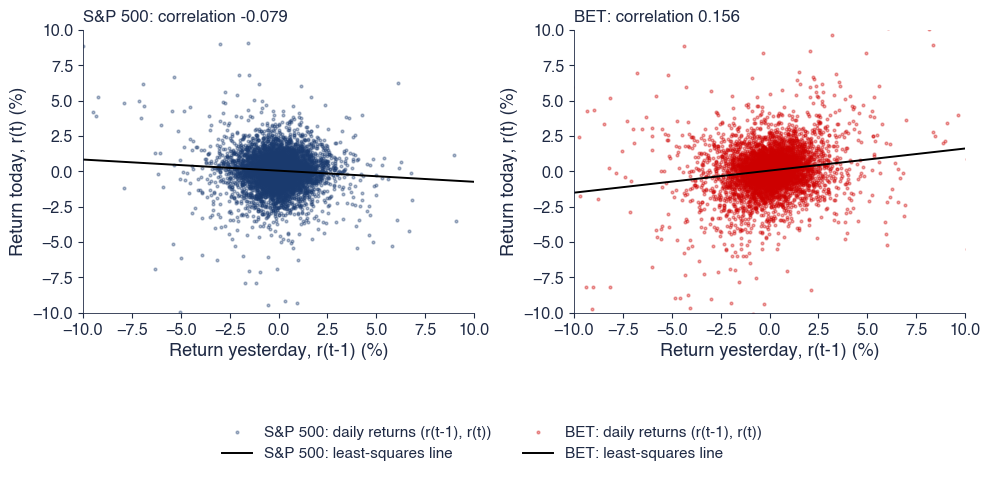

In [7]:
fig_scatter_lag(save=False)

{'mu': 0.00033087486307272466,
 'sd': 0.011336717263741808,
 'n': 9240,
 'first': '1990-01-02',
 'final': 3.0572837347919757,
 'sim_final': [2.7569085099839485,
  2.7964387811202593,
  4.501756288914057,
  2.8538890163967383]}

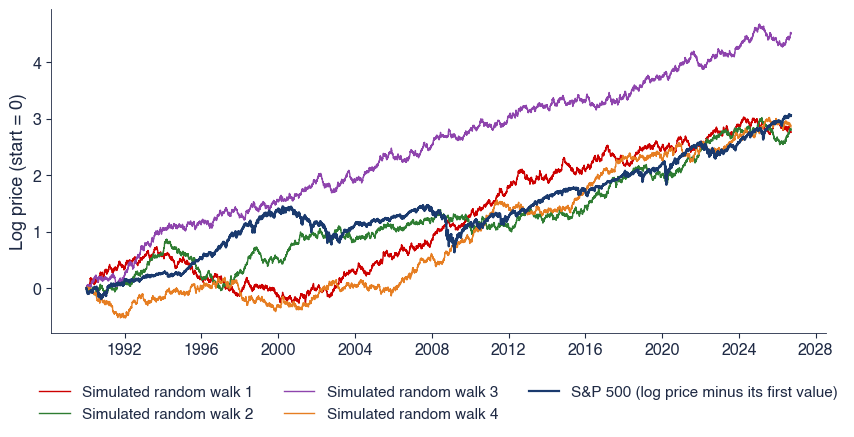

In [8]:
fig_rw_paths(save=False)

## 2. Random walk: how risk grows with the horizon

- Under a random walk, $\mathrm{sd}(r_t(q)) = \sigma\sqrt{q}$ (the square-root-of-time rule).

In [9]:
r = returns('sp500')
sigma = r.std()
pd.Series({f'{q} days': sigma * np.sqrt(q) for q in (1, 5, 20, 250)}).round(2)

1 days       1.13
5 days       2.53
20 days      5.07
250 days    17.92
dtype: float64

## 3. White noise and the ACF

- Gaussian white noise and its sample ACF (SFEtimewn).
- Theoretical and sample ACF of AR(1), AR(2), MA(1) and MA(2) processes (SFEacfar1, SFEacfar2, SFEacfma1, SFEacfma2).
- The ACF of daily returns with the i.i.d. and the robust bands; the ACF of absolute returns.

In [10]:
def fig_white_noise(n=1000, lags=30, seed=10, save=True):
    """Gaussian white noise, n = 1000 (as in SFEtimewn), and its sample ACF with the 95% band +/- 1.96/sqrt(n)."""
    rng = np.random.default_rng(seed)
    wn = rng.standard_normal(n)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), gridspec_kw={'width_ratios': [1.6, 1]})
    axes[0].plot(np.arange(1, n + 1), wn, color=st.MainBlue, lw=0.6, label='Gaussian white noise, N(0, 1)')
    axes[0].set_xlabel('t')
    axes[0].set_ylabel('x(t)')
    r = acf(wn, lags)
    axes[1].bar(np.arange(1, lags + 1), r, color=st.IDAred, width=0.5, label='Sample ACF')
    b = 1.96 / np.sqrt(n)
    axes[1].axhline(b, color='black', ls='--', lw=0.8, label='95% band: +/- 1.96/sqrt(n)')
    axes[1].axhline(-b, color='black', ls='--', lw=0.8)
    axes[1].axhline(0, color='black', lw=0.6)
    axes[1].set_xlabel('Lag k')
    axes[1].set_ylabel('rho_hat(k)')
    axes[1].set_ylim(-0.2, 0.2)
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_white_noise')
    return {'n': n, 'band': b, 'outside': int(np.sum(np.abs(r) > b)), 'lags': lags}


def arma_acf(ar=(), ma=(), lags=30):
    """Theoretical ACF of a stationary ARMA process x_t = sum a_i x_{t-i} + e_t + sum b_j e_{t-j} (via its MA(inf)
    weights, 2000 terms)."""
    psi = np.zeros(2000)
    psi[0] = 1.0
    for i in range(1, len(psi)):
        psi[i] = (ma[i - 1] if i - 1 < len(ma) else 0) + sum(ar[j] * psi[i - 1 - j] for j in range(len(ar)) if i - 1 - j >= 0)
    g = np.array([np.sum(psi[:len(psi) - k] * psi[k:]) for k in range(lags + 1)])
    return g[1:] / g[0]


def simulate_arma(ar=(), ma=(), n=1000, burn=200, rng=None):
    """x_t = sum a_i x_{t-i} + e_t + sum b_j e_{t-j}, e_t standard Normal."""
    rng = rng or np.random.default_rng(SEED)
    e = rng.standard_normal(n + burn)
    x = np.zeros(n + burn)
    for t in range(n + burn):
        x[t] = e[t] + sum(ar[i] * x[t - 1 - i] for i in range(len(ar)) if t - 1 - i >= 0) \
            + sum(ma[j] * e[t - 1 - j] for j in range(len(ma)) if t - 1 - j >= 0)
    return x[burn:]


def fig_acf_processes(lags=20, n=1000, seed=123, save=True):
    """Theoretical ACF (bars) and sample ACF of a simulated path of n = 1000 (points) for the AR(1), AR(2), MA(1)
    and MA(2) processes of the SFE Quantlets SFEacfar1, SFEacfar2, SFEacfma1 and SFEacfma2."""
    rng = np.random.default_rng(seed)
    fig, axes = plt.subplots(2, 3, figsize=(11, 5.6), sharey=True)
    out = {}
    for ax, (lab, ar, ma) in zip(axes.flat, ACF_CASES):
        th = arma_acf(ar, ma, lags)
        sm_ = acf(simulate_arma(ar, ma, n, rng=rng), lags)
        k = np.arange(1, lags + 1)
        ax.bar(k, th, color=st.MainBlue, width=0.55, label='Theoretical ACF')
        ax.plot(k, sm_, 'o', ms=3.5, color=st.IDAred, label='Sample ACF, n = 1000')
        ax.axhline(0, color='black', lw=0.6)
        ax.set_title(lab, loc='left', fontsize=11)
        ax.set_ylim(-1, 1)
        ax.set_xlabel('Lag k')
        out[lab] = [float(v) for v in th[:5]]
    axes[0, 0].set_ylabel('rho(k)')
    axes[1, 0].set_ylabel('rho(k)')
    st.fig_legend_bottom(fig, handles=axes[0, 0].get_legend_handles_labels()[0],
                         labels=axes[0, 0].get_legend_handles_labels()[1], ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_acf_processes')
    return out


def fig_acf_returns(names=ASSETS, lags=20, save=True):
    """Sample ACF of daily returns (lags 1-20) with the i.i.d. band +/- 1.96/sqrt(T) and the heteroskedasticity-robust
    band +/- 1.96 sqrt(delta_hat(k)/T)."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.6), sharex=True)
    out = {}
    k = np.arange(1, lags + 1)
    for ax, n in zip(axes.flat, names):
        x = returns(n).values
        r = acf(x, lags)
        rb = 1.96 * np.sqrt(robust_var_acf(x, lags))
        b = 1.96 / np.sqrt(len(x))
        ax.bar(k, r, color=COLORS[n], width=0.55, label='Sample ACF of the returns')
        ax.fill_between(k, -rb, rb, color=st.Teal, alpha=0.18, lw=0, label='Robust 95% band')
        ax.axhline(b, color='black', ls='--', lw=0.8, label='i.i.d. 95% band')
        ax.axhline(-b, color='black', ls='--', lw=0.8)
        ax.axhline(0, color='black', lw=0.6)
        ax.set_title(NAME[n], loc='left', fontsize=12)
        ax.set_ylim(-0.2, 0.2)
        out[n] = {'rho': [float(v) for v in r[:5]], 'band_iid': float(b), 'band_rob1': float(rb[0]),
                  'out_iid': int(np.sum(np.abs(r) > b)), 'out_rob': int(np.sum(np.abs(r) > rb))}
    for ax in axes[1]:
        ax.set_xlabel('Lag k (days)')
    st.fig_legend_bottom(fig, handles=axes[0, 0].get_legend_handles_labels()[0],
                         labels=axes[0, 0].get_legend_handles_labels()[1], ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_acf_returns')
    return out


def fig_acf_abs(names=('sp500', 'bet', 'btc'), lags=100, save=True):
    """ACF of the returns and of the absolute returns, lags 1-100: returns almost uncorrelated, |returns| strongly
    and persistently correlated (volatility clustering)."""
    fig, ax = plt.subplots(figsize=(10, 4.0))
    out = {}
    k = np.arange(1, lags + 1)
    for n in names:
        x = returns(n).values
        ra = acf(np.abs(x), lags)
        r = acf(x, lags)
        ax.plot(k, ra, color=COLORS[n], lw=1.6, label=f'{NAME[n]}: |returns|')
        ax.plot(k, r, color=COLORS[n], lw=0.9, ls=':', label=f'{NAME[n]}: returns')
        out[n] = {'abs1': float(ra[0]), 'abs20': float(ra[19]), 'abs100': float(ra[99]), 'ret1': float(r[0])}
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xlabel('Lag k (days)')
    ax.set_ylabel('Sample autocorrelation')
    st.legend_outside_bottom(ax, ncol=3, y=-0.16)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_acf_abs')
    return out

{'n': 1000, 'band': np.float64(0.061980642139300234), 'outside': 0, 'lags': 30}

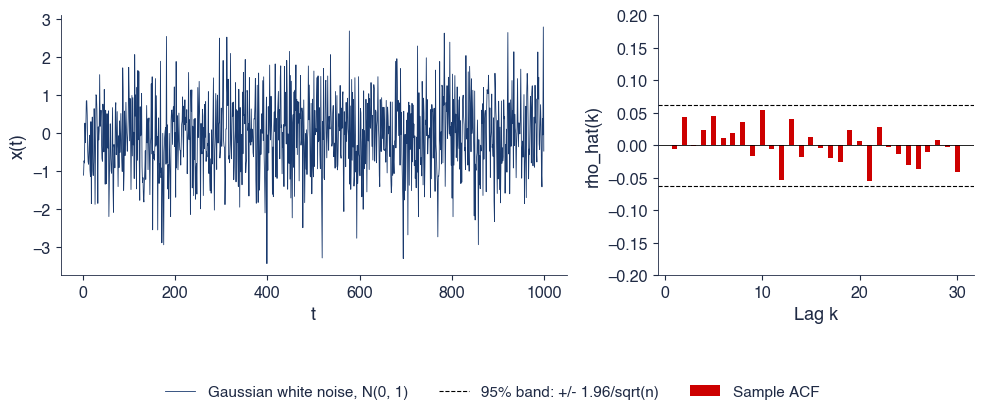

In [11]:
fig_white_noise(save=False)

{'AR(1), alpha = 0.9': [0.9,
  0.8099999999999999,
  0.7290000000000001,
  0.6561000000000001,
  0.5904900000000001],
 'AR(1), alpha = -0.9': [-0.9,
  0.8099999999999999,
  -0.7290000000000001,
  0.6561000000000001,
  -0.5904900000000001],
 'AR(2), alpha1 = 0.5, alpha2 = 0.4': [0.8333333333333336,
  0.816666666666667,
  0.7416666666666668,
  0.6974999999999999,
  0.6454166666666667],
 'MA(1), beta = 0.5': [0.4, 0.0, 0.0, 0.0, 0.0],
 'MA(1), beta = -0.5': [-0.4, 0.0, 0.0, 0.0, 0.0],
 'MA(2), beta1 = 0.5, beta2 = 0.4': [0.4964539007092198,
  0.2836879432624113,
  0.0,
  0.0,
  0.0]}

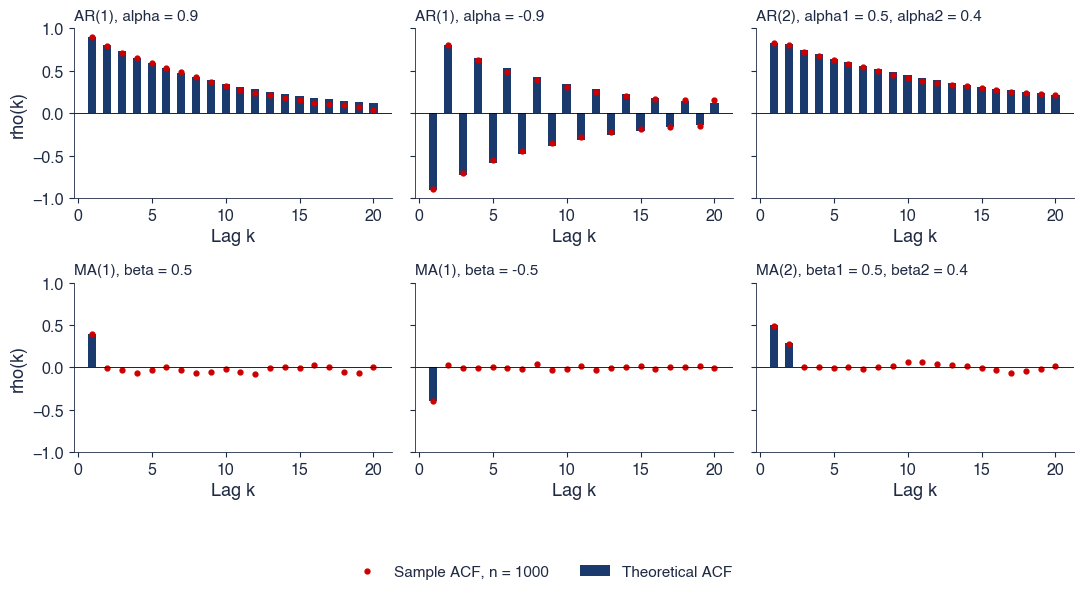

In [12]:
fig_acf_processes(save=False)

{'sp500': {'rho': [-0.07868231036241596,
   -0.0041494257757456465,
   -0.00618504287606054,
   -0.0224354115805981,
   -0.015800398719636358],
  'band_iid': 0.020390134275123734,
  'band_rob1': 0.04558562451103002,
  'out_iid': 9,
  'out_rob': 3},
 'dax': {'rho': [-0.00942471720295888,
   -0.010996372342151414,
   -0.01482363171652909,
   0.01867179365908994,
   -0.021723281931000593],
  'band_iid': 0.020337378341246548,
  'band_rob1': 0.030464404586619483,
  'out_iid': 5,
  'out_rob': 0},
 'bet': {'rho': [0.15622675373838288,
   0.03261045393948151,
   -0.008413504914020813,
   0.0008720479937497463,
   0.030686215096082506],
  'band_iid': 0.023030153294968055,
  'band_rob1': 0.051190174239595404,
  'out_iid': 6,
  'out_rob': 2},
 'btc': {'rho': [-0.02230531534360892,
   0.012108461873084505,
   0.010713871654821242,
   0.010327801135001018,
   0.01017914597649045],
  'band_iid': 0.02960198257317867,
  'band_rob1': 0.05035775949793655,
  'out_iid': 3,
  'out_rob': 0}}

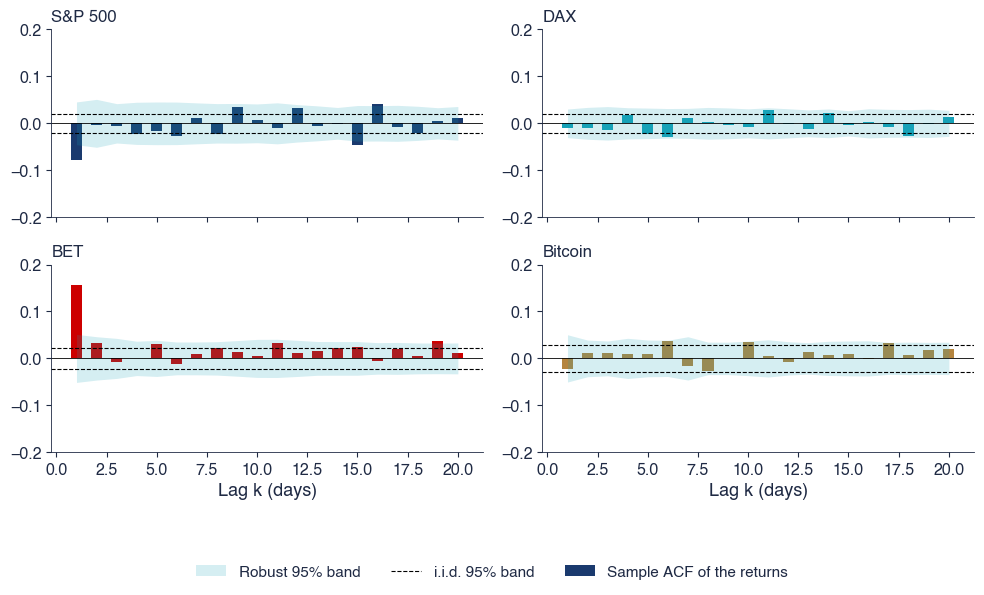

In [13]:
fig_acf_returns(save=False)

{'sp500': {'abs1': 0.27457690681032093,
  'abs20': 0.2177904232269542,
  'abs100': 0.09155859053334124,
  'ret1': -0.07868231036241596},
 'bet': {'abs1': 0.4139534511009567,
  'abs20': 0.16721008985463753,
  'abs100': 0.10680496401943634,
  'ret1': 0.15622675373838288},
 'btc': {'abs1': 0.21265159924664476,
  'abs20': 0.09268499140961477,
  'abs100': 0.023756623458832445,
  'ret1': -0.02230531534360892}}

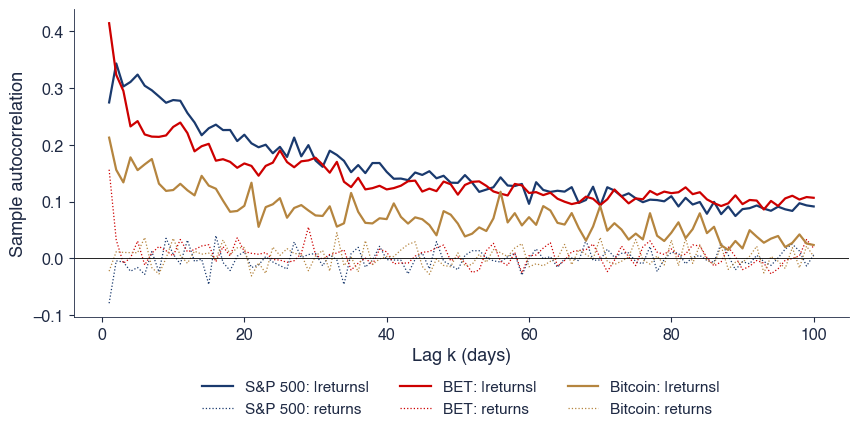

In [14]:
fig_acf_abs(save=False)

## 4. Autocorrelation tests

- $Q_{BP}(10)$, $Q_{LB}(10)$ and the robust $\tilde Q(10)$ on returns and squared returns; the runs test.

In [15]:
def tests_table(names=ASSETS + STOCKS):
    """Portmanteau tests (m = 10) on returns and on squared returns, and the runs test, for each series."""
    out = {}
    for k in names:
        x = returns(k).values
        out[k] = {'ret': portmanteau(x), 'sq': portmanteau(x ** 2), 'runs': runs_test(x), 'n': len(x)}
    return out

In [16]:
tt = tests_table()
pd.DataFrame({NAME[k]: {'rho1': v['ret']['rho1'], 'LB(10)': v['ret']['lb'], 'p LB': v['ret']['p_lb'], 'robust Q(10)': v['ret']['rob'], 'p robust': v['ret']['p_rob'], 'LB(10) squared': v['sq']['lb'], 'runs z': v['runs']['z'], 'p runs': v['runs']['p']} for k, v in tt.items()}).T.round(3)

,rho1,LB(10),p LB,robust Q(10),p robust,LB(10) squared,runs z,p runs
S&P 500,-0.079,90.753,0.000,18.814,0.043,8014.689,2.974,0.003
DAX,-0.009,21.829,0.016,8.593,0.571,3747.268,1.731,0.084
BET,0.156,198.275,0.000,42.909,0.000,2500.373,-7.749,0.000
Bitcoin,-0.022,20.178,0.028,11.869,0.294,212.745,2.676,0.007
Banca Transilvania,0.010,29.108,0.001,13.244,0.210,480.618,-1.681,0.093
OMV Petrom,-0.015,20.705,0.023,9.935,0.446,505.071,1.723,0.085
BRD,0.032,19.890,0.030,10.773,0.375,416.079,-3.038,0.002
Transgaz,0.055,28.741,0.001,12.333,0.263,639.172,1.492,0.136


## 5. Unit roots: prices against returns

- ADF (lag order by AIC), Phillips–Perron and KPSS on log prices (constant and trend) and on returns (constant).
- The spurious regression of two independent random walks (Granger and Newbold, 1974).

In [17]:
def unit_root_table(names=ASSETS + STOCKS):
    """ADF, PP and KPSS on log prices (constant and trend) and on returns (constant)."""
    out = {}
    for k in names:
        p, r = log_price(k).values, returns(k).values
        out[k] = {'price': {'adf': adf_test(p, 'ct'), 'pp': pp_test(p, 'ct'), 'kpss': kpss_test(p, 'ct')},
                  'ret': {'adf': adf_test(r, 'c'), 'pp': pp_test(r, 'c'), 'kpss': kpss_test(r, 'c')},
                  'n': len(r), 'first': returns(k).index[0].date().isoformat()}
    return out


def fig_unit_root(k='bet', save=True):
    """Log price and daily returns of one series, with the ADF and KPSS statistics of each."""
    lp, r = log_price(k), returns(k)
    a_p, k_p = adf_test(lp.values, 'ct'), kpss_test(lp.values, 'ct')
    a_r, k_r = adf_test(r.values, 'c'), kpss_test(r.values, 'c')
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    axes[0].plot(lp.index, lp.values, color=COLORS.get(k, st.MainBlue), lw=1.1, label=f'{NAME[k]}: log price')
    axes[0].set_title(f'Log price: ADF {a_p["stat"]:.2f}, KPSS {k_p["stat"]:.2f}', loc='left', fontsize=11)
    axes[1].plot(r.index, r.values, color=st.MainBlue, lw=0.4, label=f'{NAME[k]}: daily log return (%)')
    axes[1].set_title(f'Returns: ADF {a_r["stat"]:.1f}, KPSS {k_r["stat"]:.2f}', loc='left', fontsize=11)
    st.fig_legend_bottom(fig, ncol=2, y=0.0)
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig(f'sfm_ch7_unit_root_{k}')
    return {'price': {'adf': a_p, 'kpss': k_p}, 'ret': {'adf': a_r, 'kpss': k_r}}


def spurious(T=500, reps=2000, seed=SEED):
    """Regress one random walk on another, independent one: share of |t| > 1.96 and median R^2
    (Granger and Newbold, 1974); the same for their increments (white noise)."""
    rng = np.random.default_rng(seed)
    res = {'level': [], 'diff': []}
    keep = None
    for i in range(reps):
        e1, e2 = rng.standard_normal(T), rng.standard_normal(T)
        y, x = np.cumsum(e1), np.cumsum(e2)
        for lab, (yy, xx) in [('level', (y, x)), ('diff', (e1, e2))]:
            X = np.column_stack([np.ones(T), xx])
            b, *_ = np.linalg.lstsq(X, yy, rcond=None)
            u = yy - X @ b
            se = np.sqrt(np.sum(u ** 2) / (T - 2) * np.linalg.inv(X.T @ X)[1, 1])
            r2 = 1 - np.sum(u ** 2) / np.sum((yy - yy.mean()) ** 2)
            res[lab].append((b[1] / se, r2))
        if i == 0:
            keep = (y, x)
    out = {lab: {'reject': float(np.mean([abs(t) > 1.96 for t, _ in v])), 'r2_med': float(np.median([r for _, r in v])),
                 'beyond40': float(np.mean([abs(t) > 40 for t, _ in v])),
                 't': [float(t) for t, _ in v]} for lab, v in res.items()}
    out['example'] = keep
    return out


def fig_spurious(sp, save=True):
    """Two independent random walks, and the distribution of the t-statistic of the slope when one is regressed on
    the other (levels) and on the increments."""
    y, x = sp['example']
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.9))
    axes[0].plot(y, color=st.MainBlue, lw=1.1, label='Random walk y(t)')
    axes[0].plot(x, color=st.IDAred, lw=1.1, label='Independent random walk x(t)')
    axes[0].set_xlabel('t')
    bins = np.linspace(-40, 40, 81)                     # |t| > 40 (a few regressions in levels) not drawn
    axes[1].hist(sp['level']['t'], bins=bins, density=True, color=st.Amber, alpha=0.8,
                 label='t-statistic, regression in levels')
    axes[1].hist(sp['diff']['t'], bins=bins, density=True, color=st.Forest, alpha=0.7, label='t-statistic, regression in increments')
    g = np.linspace(-40, 40, 400)
    axes[1].plot(g, stats.norm.pdf(g), color='black', lw=1, label='N(0, 1)')
    axes[1].set_xlabel('t-statistic of the slope')
    st.fig_legend_bottom(fig, ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_spurious')

In [18]:
ur = unit_root_table()
pd.DataFrame({NAME[k]: {f'{s_} {t}': v[s_][t]['stat'] for s_ in ['price', 'ret'] for t in ['adf', 'pp', 'kpss']} for k, v in ur.items()}).T.round(2)

,price adf,price pp,price kpss,ret adf,ret pp,ret kpss
S&P 500,-1.47,-1.57,2.23,-17.61,-105.05,0.12
DAX,-2.69,-2.65,0.94,-23.30,-97.40,0.04
BET,-1.73,-1.54,2.30,-13.65,-74.47,0.12
Bitcoin,-1.48,-1.54,1.81,-20.16,-67.84,0.13
Banca Transilvania,-3.46,-3.35,0.57,-12.96,-60.79,0.23
OMV Petrom,-0.80,-0.74,2.50,-19.50,-62.71,0.29
BRD,-2.18,-2.19,1.64,-59.46,-59.53,0.29
Transgaz,-0.96,-0.92,0.71,-39.90,-57.83,0.22


{'price': {'adf': {'stat': -1.7322713688387346,
   'p': 0.7364650367017338,
   'lags': 29,
   'nobs': 7214,
   'crit5': -3.4110987681503095},
  'kpss': {'stat': 2.3003314706242275, 'p': 0.01, 'lags': 36, 'crit5': 0.146}},
 'ret': {'adf': {'stat': -13.645753152530824,
   'p': 1.6208766827222266e-25,
   'lags': 28,
   'nobs': 7214,
   'crit5': -2.8619407329752864},
  'kpss': {'stat': 0.11525234436000918, 'p': 0.1, 'lags': 36, 'crit5': 0.463}}}

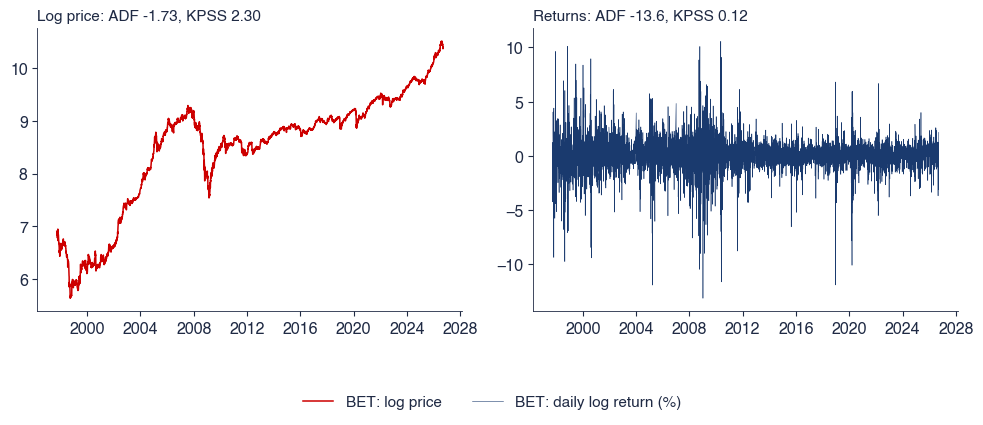

In [19]:
fig_unit_root('bet', save=False)

{'level': (0.898, 0.166), 'diff': (0.055, 0.001)}


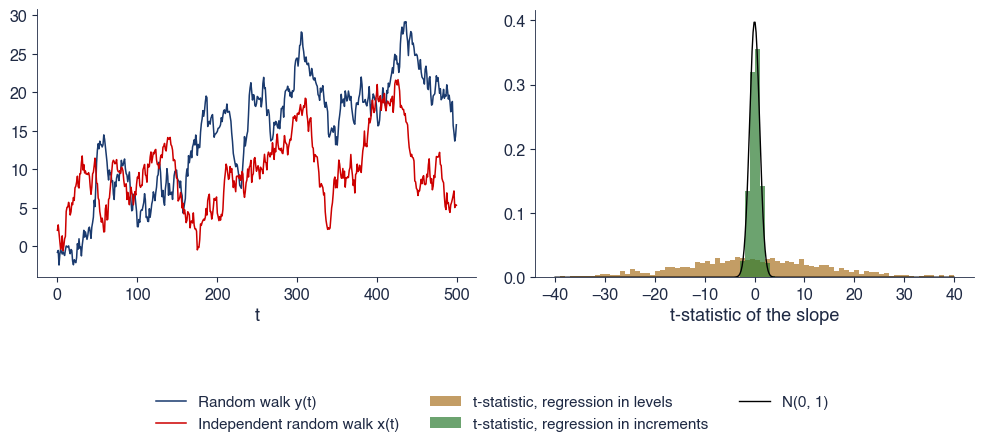

In [20]:
sp = spurious()
print({lab: (sp[lab]['reject'], round(sp[lab]['r2_med'], 3)) for lab in ['level', 'diff']})
fig_spurious(sp, save=False)

## 6. Variance-ratio tests

- Lo–MacKinlay VR(q) with $Z(q)$ and $Z^*(q)$; the Chow–Denning test; Choi's automatic VR test with the wild bootstrap of Kim (2009).
- A Monte Carlo study: how often do $Z$ and $Z^*$ reject a true null under GARCH returns?

In [21]:
def vr_table(names=ASSETS + STOCKS, start=None):
    """VR(q), Z(q), Z*(q) for q in QS; the Chow-Denning test; the automatic VR test; rho_hat(1)."""
    out = {}
    for k in names:
        r = returns(k, start)
        x = r.values
        out[k] = {'n': len(x), 'first': r.index[0].date().isoformat(), 'rho1': float(acf(x, 1)[0]),
                  'vr': {q: variance_ratio(x, q) for q in QS}, 'cd': chow_denning(x), 'avr': auto_vr(x)}
    return out


def fig_vr_profile(names=ASSETS, qmax=40, save=True):
    """VR(q), q = 2..40, with the robust and the i.i.d. 95% bands around 1."""
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.8), sharex=True)
    out = {}
    for ax, k in zip(axes.flat, names):
        qs, vr, se, se0 = vr_profile(returns(k).values, qmax)
        ax.plot(qs, vr, color=COLORS[k], lw=1.8, marker='o', ms=2.5, label='VR(q)')
        ax.fill_between(qs, 1 - 1.96 * se, 1 + 1.96 * se, color=st.Teal, alpha=0.18, lw=0, label='Robust 95% band (Z*)')
        ax.plot(qs, 1 + 1.96 * se0, color='black', ls='--', lw=0.8, label='i.i.d. 95% band (Z)')
        ax.plot(qs, 1 - 1.96 * se0, color='black', ls='--', lw=0.8)
        ax.axhline(1, color='black', lw=0.6)
        ax.set_title(NAME[k], loc='left', fontsize=12)
        out[k] = {'vr40': float(vr[-1]), 'vrmin': float(vr.min()), 'vrmax': float(vr.max())}
    for ax in axes[1]:
        ax.set_xlabel('Horizon q (days)')
    for ax in axes[:, 0]:
        ax.set_ylabel('VR(q)')
    st.fig_legend_bottom(fig, handles=axes[0, 0].get_legend_handles_labels()[0],
                         labels=axes[0, 0].get_legend_handles_labels()[1], ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.06, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_vr_profile')
    return out


def simulate_garch(T, omega=0.04, a=0.12, b=0.86, burn=500, rng=None):
    """A GARCH(1,1) martingale difference: e_t = sigma_t z_t, sigma_t^2 = omega + a e_{t-1}^2 + b sigma_{t-1}^2,
    z_t standard Normal (unconditional variance omega / (1 - a - b) = 2)."""
    rng = rng or np.random.default_rng(SEED)
    z = rng.standard_normal(T + burn)
    e = np.empty(T + burn)
    s2 = omega / (1 - a - b)
    for t in range(T + burn):
        e[t] = np.sqrt(s2) * z[t]
        s2 = omega + a * e[t] ** 2 + b * s2
    return e[burn:]


def vr_size(T=2000, reps=1000, qs=(2, 5, 10), seed=SEED):
    """Rejection rates at 5% of Z(q) and Z*(q) when the null of no predictability is TRUE: i.i.d. Normal returns
    and GARCH(1,1) returns (uncorrelated, but with volatility clustering)."""
    rng = np.random.default_rng(seed)
    out = {'iid': {q: [0, 0] for q in qs}, 'garch': {q: [0, 0] for q in qs}}
    for _ in range(reps):
        for lab, x in [('iid', rng.standard_normal(T)), ('garch', simulate_garch(T, rng=rng))]:
            for q in qs:
                v = variance_ratio(x, q)
                out[lab][q][0] += abs(v['z']) > 1.96
                out[lab][q][1] += abs(v['zs']) > 1.96
    return {lab: {q: {'z': c[0] / reps, 'zs': c[1] / reps} for q, c in d.items()} for lab, d in out.items()}


def fig_vr_size(sz, save=True):
    """Rejection rates at 5% of Z(q) and Z*(q) under i.i.d. and GARCH(1,1) returns (the null hypothesis is true)."""
    qs = list(sz['iid'])
    fig, ax = plt.subplots(figsize=(10, 3.9))
    w = 0.2
    xs = np.arange(len(qs))
    for i, (lab, key, col) in enumerate([('i.i.d. returns, Z', ('iid', 'z'), st.MainBlue), ('i.i.d. returns, Z*', ('iid', 'zs'), st.Teal),
                                         ('GARCH returns, Z', ('garch', 'z'), st.IDAred), ('GARCH returns, Z*', ('garch', 'zs'), st.Amber)]):
        ax.bar(xs + (i - 1.5) * w, [100 * sz[key[0]][q][key[1]] for q in qs], width=w * 0.95, color=col, label=lab)
    ax.axhline(5, color='black', ls='--', lw=0.9, label='Nominal level: 5%')
    ax.set_xticks(xs)
    ax.set_xticklabels([f'q = {q}' for q in qs])
    ax.set_ylabel('Rejections of a true null (%)')
    st.legend_outside_bottom(ax, ncol=5, y=-0.13)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_vr_size')

In [22]:
vt = vr_table()
pd.DataFrame({NAME[k]: {**{f'VR({q})': v['vr'][q]['vr'] for q in QS}, **{f'Z*({q})': v['vr'][q]['zs'] for q in QS}, 'CD': v['cd']['cd'], 'p CD': v['cd']['p'], 'AVR': v['avr']['stat'], 'k': v['avr']['k'], 'p AVR': v['avr']['p_boot']} for k, v in vt.items()}).T.round(3)

,VR(2),VR(5),VR(10),VR(20),Z*(2),Z*(5),Z*(10),Z*(20),CD,p CD,AVR,k,p AVR
S&P 500,0.922,0.856,0.783,0.767,-3.375,-2.756,-2.732,-2.062,3.375,0.003,-5.214,3.688,0.006
DAX,0.990,0.968,0.932,0.925,-0.614,-0.885,-1.207,-0.910,1.207,0.644,-0.388,1.666,0.608
BET,1.156,1.283,1.362,1.517,5.987,5.247,4.740,4.939,5.987,0.000,8.858,5.627,0.000
Bitcoin,0.977,0.991,1.027,1.094,-0.883,-0.185,0.371,0.910,0.910,0.835,-1.010,2.004,0.352
Banca Transilvania,1.009,0.997,0.954,0.995,0.336,-0.040,-0.483,-0.037,0.483,0.981,0.313,1.474,0.718
OMV Petrom,0.985,0.960,0.975,1.038,-0.526,-0.676,-0.291,0.316,0.676,0.937,-0.532,1.692,0.562
BRD,1.032,1.083,1.078,1.107,1.284,1.550,0.970,0.957,1.550,0.403,1.582,2.341,0.152
Transgaz,1.055,1.150,1.142,1.166,2.045,2.597,1.688,1.444,2.597,0.037,3.780,2.958,0.004


{'sp500': {'vr40': 0.7243931239828475,
  'vrmin': 0.7243931239828475,
  'vrmax': 0.9215128101162515},
 'dax': {'vr40': 0.914198044826955,
  'vrmin': 0.911604649246913,
  'vrmax': 0.9904579543783915},
 'bet': {'vr40': 1.7433190268940846,
  'vrmin': 1.1563758000198159,
  'vrmax': 1.7433190268940846},
 'btc': {'vr40': 1.1940701302329633,
  'vrmin': 0.9770573856686801,
  'vrmax': 1.1940701302329633}}

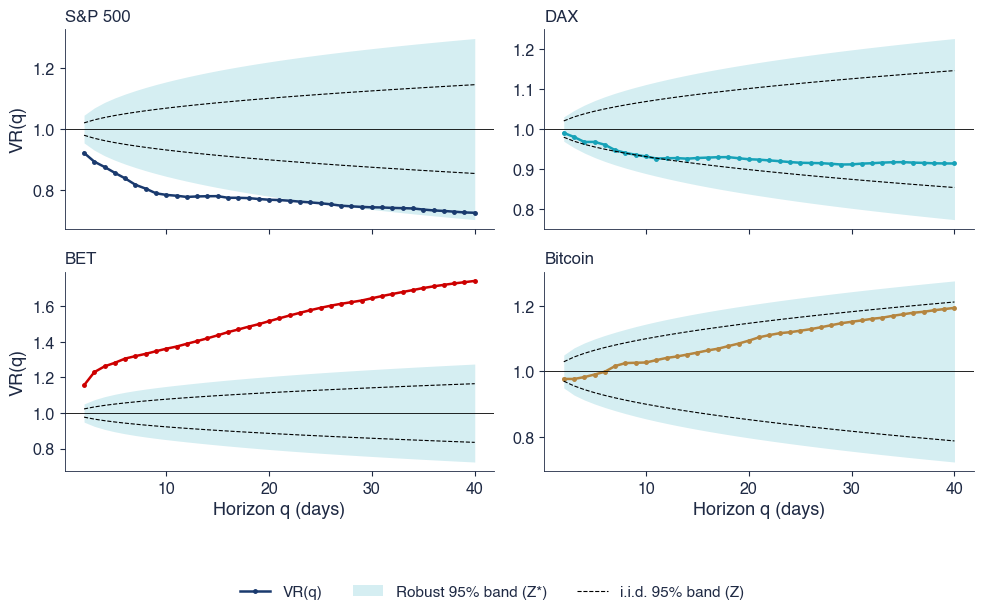

In [23]:
fig_vr_profile(save=False)

z     zs
iid   2   0.045  0.047
      5   0.047  0.048
      10  0.047  0.046
garch 2   0.171  0.047
      5   0.156  0.031
      10  0.154  0.037

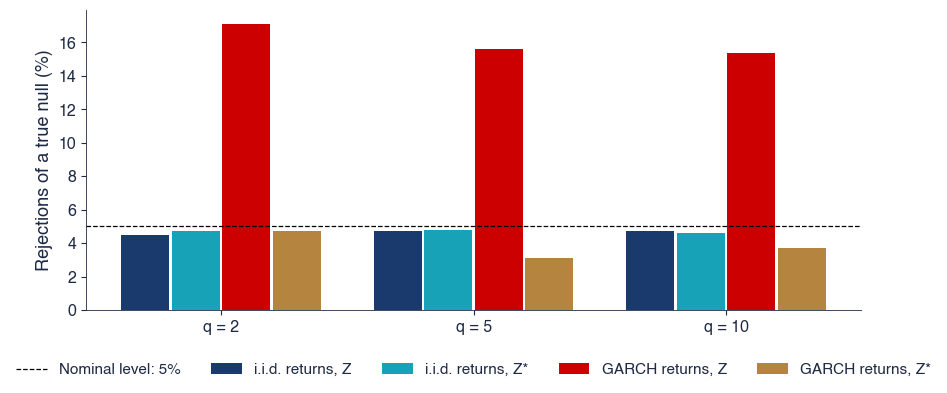

In [24]:
sz = vr_size()
fig_vr_size(sz, save=False)
pd.DataFrame({(lab, q): r for lab, d in sz.items() for q, r in d.items()}).T

## 7. Efficiency across markets and over time

- VR(5) over the last ten years for developed, emerging and crypto markets.
- Rolling VR(5) on 500-day windows (the adaptive markets hypothesis); three sub-periods per market.

In [25]:
def markets_table(names=DEVELOPED + EMERGING + CRYPTO, start=MARKETS_START, q=5):
    """VR(5) with the robust Z*, rho_hat(1) and the Chow-Denning p-value over the last ten years of data."""
    out = {}
    for k in names:
        x = returns(k, start).values
        v = variance_ratio(x, q)
        out[k] = {'vr': v['vr'], 'zs': v['zs'], 'se': v['se_rob'], 'rho1': float(acf(x, 1)[0]), 'cd_p': chow_denning(x)['p'],
                  'n': len(x), 'group': 'Developed' if k in DEVELOPED else 'Crypto' if k in CRYPTO else 'Emerging'}
    return out


def fig_vr_markets(mt, save=True):
    """VR(5) with its robust 95% interval, by market, over the last ten years."""
    keys = sorted(mt, key=lambda k: mt[k]['vr'])
    gcol = {'Developed': st.MainBlue, 'Emerging': st.IDAred, 'Crypto': st.Amber}
    fig, ax = plt.subplots(figsize=(10, 4.6))
    for i, k in enumerate(keys):
        m = mt[k]
        ax.errorbar(m['vr'], i, xerr=1.96 * m['se'], fmt='o', color=gcol[m['group']], ms=5, capsize=3, lw=1.2)
    for g, c in gcol.items():
        ax.plot([], [], 'o', color=c, label=f'{g} markets')
    ax.axvline(1, color='black', lw=0.8, ls='--', label='VR = 1 (random walk)')
    ax.set_yticks(range(len(keys)))
    ax.set_yticklabels([NAME[k] for k in keys])
    ax.set_xlabel('VR(5) with robust 95% interval')
    st.legend_outside_bottom(ax, ncol=4, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_vr_markets')


def rolling_vr(k, q=5, window=WINDOW, step=STEP):
    """VR(q) and Z*(q) on rolling windows of `window` days, one every `step` days (dated at the window end)."""
    r = returns(k)
    x = r.values
    rows = []
    for end in range(window, len(x) + 1, step):
        v = variance_ratio(x[end - window:end], q)
        rows.append((r.index[end - 1], v['vr'], v['zs']))
    return pd.DataFrame(rows, columns=['date', 'vr', 'zs']).set_index('date')


def fig_rolling_vr(names=('sp500', 'bet', 'btc'), q=5, save=True):
    """Rolling VR(5) and Z*(5) on 500-day windows (adaptive markets: efficiency changes over time)."""
    fig, axes = plt.subplots(2, 1, figsize=(10, 5.6), sharex=True)
    out = {}
    for k in names:
        d = rolling_vr(k, q)
        axes[0].plot(d.index, d['vr'], color=COLORS[k], lw=1.3, label=NAME[k])
        axes[1].plot(d.index, d['zs'], color=COLORS[k], lw=1.1)
        out[k] = {'share_rej': float(np.mean(np.abs(d['zs']) > 1.96)), 'share_pos': float(np.mean(d['zs'] > 1.96)),
                  'share_neg': float(np.mean(d['zs'] < -1.96)), 'n_win': len(d), 'vr_min': float(d['vr'].min()),
                  'vr_max': float(d['vr'].max()), 'date_max': d['vr'].idxmax().date().isoformat(),
                  'date_min': d['vr'].idxmin().date().isoformat(), 'first': d.index[0].date().isoformat()}
    axes[0].axhline(1, color='black', lw=0.7, ls='--')
    axes[0].set_ylabel(f'VR({q})')
    axes[1].axhline(1.96, color='black', lw=0.7, ls='--')
    axes[1].axhline(-1.96, color='black', lw=0.7, ls='--')
    axes[1].set_ylabel(f'Robust Z*({q})')
    st.fig_legend_bottom(fig, handles=axes[0].get_legend_handles_labels()[0], labels=axes[0].get_legend_handles_labels()[1], ncol=3, y=0.0)
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_rolling_vr')
    return out


def subperiods(table=SUBPERIODS, q=5):
    """rho_hat(1), VR(5), Z*(5) and the Chow-Denning p-value in three sub-periods."""
    out = {}
    for k, per in table.items():
        r = returns(k)
        out[k] = []
        for a, b in per:
            x = r.loc[a:b].values
            v = variance_ratio(x, q)
            out[k].append({'from': r.loc[a:b].index[0].date().isoformat(), 'to': r.loc[a:b].index[-1].date().isoformat(),
                           'n': len(x), 'rho1': float(acf(x, 1)[0]), 'vr': v['vr'], 'zs': v['zs'], 'cd_p': chow_denning(x)['p']})
    return out

,vr,zs,se,rho1,cd_p,n,group
sp500,0.838532,-1.216276,0.132756,-0.14364,0.07701,2512,Developed
dax,1.024983,0.333497,0.074913,-0.028603,0.784226,2537,Developed
stoxx50,1.016764,0.208909,0.080246,-0.028129,0.84967,2557,Developed
nikkei,0.941568,-0.64616,0.090429,-0.043318,0.779128,2441,Developed
bet,1.200495,2.03035,0.098749,0.062858,0.158837,2492,Emerging
wig20,0.979466,-0.267666,0.076715,-0.025944,0.93765,2498,Emerging
bux,1.033325,0.333499,0.099924,0.001303,0.995342,2492,Emerging
px,1.205691,2.079333,0.098921,0.042677,0.142081,2504,Emerging
bist,1.085518,1.339611,0.063838,0.000972,0.548698,2507,Emerging
bvsp,0.886388,-0.728945,0.155858,-0.123565,0.308802,2483,Emerging


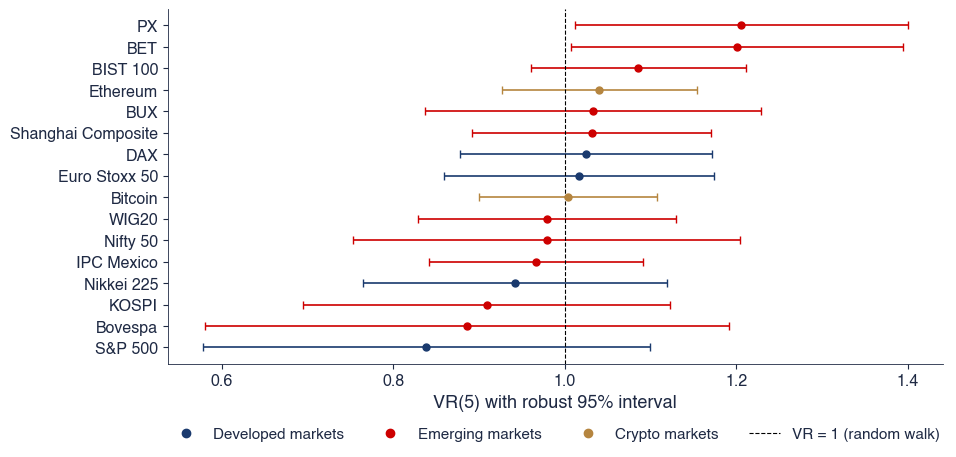

In [26]:
mt = markets_table()
fig_vr_markets(mt, save=False)
pd.DataFrame(mt).T.round(3)

{'sp500': {'share_rej': 0.03836930455635491,
  'share_pos': 0.0,
  'share_neg': 0.03836930455635491,
  'n_win': 417,
  'vr_min': 0.5894233096195152,
  'vr_max': 1.1077210713830632,
  'date_max': '1992-03-24',
  'date_min': '2008-09-29',
  'first': '1991-12-23'},
 'bet': {'share_rej': 0.2888198757763975,
  'share_pos': 0.2888198757763975,
  'share_neg': 0.0,
  'n_win': 322,
  'vr_min': 0.7912563466010268,
  'vr_max': 1.8047690528621163,
  'date_max': '2000-01-20',
  'date_min': '2011-08-02',
  'first': '1999-09-14'},
 'btc': {'share_rej': 0.0,
  'share_pos': 0.0,
  'share_neg': 0.0,
  'n_win': 185,
  'vr_min': 0.7811067061855379,
  'vr_max': 1.167454318718109,
  'date_max': '2023-10-14',
  'date_min': '2026-04-04',
  'first': '2016-01-30'}}

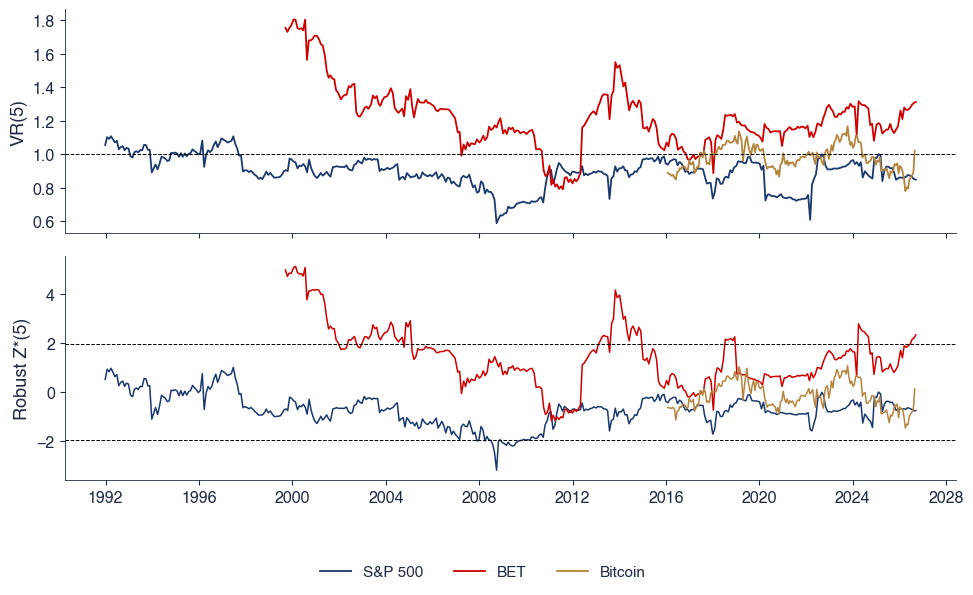

In [27]:
fig_rolling_vr(save=False)

In [28]:
sub = subperiods()
pd.DataFrame([dict(market=k, **r) for k, rows in sub.items() for r in rows]).round(3)

,market,from,to,n,rho1,vr,zs,cd_p
0,bet,1997-09-22,2006-12-19,2306,0.270,1.496,6.146,0.000
1,bet,2007-01-03,2016-12-30,2516,0.066,1.075,0.817,0.262
2,bet,2017-01-03,2026-09-18,2421,0.064,1.203,2.045,0.154
3,sp500,1990-01-03,2001-12-31,3025,0.017,0.964,-0.624,0.334
4,sp500,2002-01-02,2013-12-31,3019,-0.100,0.800,-2.527,0.010
5,sp500,2014-01-02,2026-09-18,3196,-0.124,0.849,-1.300,0.080
6,btc,2014-09-18,2017-12-31,1201,0.028,0.975,-0.234,0.983
7,btc,2018-01-01,2021-12-31,1461,-0.058,0.984,-0.211,0.374
8,btc,2022-01-01,2026-09-18,1722,-0.026,1.013,0.180,0.924


## 8. Calendar anomalies

- Mean daily return by weekday and January against the other months, with Newey–West (HAC) standard errors.

In [29]:
def calendar(k):
    """Mean daily return by weekday and January against the other months; Wald tests with Newey-West (HAC)
    standard errors (5 lags) in regressions on dummies."""
    r = returns(k)
    d = pd.get_dummies(r.index.dayofweek).astype(float).values
    res = sm.OLS(r.values, d).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    R = np.column_stack([np.ones(4), -np.eye(4)])               # Monday = Tuesday = ... = Friday
    w = res.wald_test(R, scalar=True)
    jan = (r.index.month == 1).astype(float)
    rj = sm.OLS(r.values, sm.add_constant(jan)).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    means = [float(r[r.index.dayofweek == i].mean()) for i in range(5)]
    ses = [float(v) for v in res.bse]
    return {'means': means, 'ses': ses, 'wald_p': float(w.pvalue), 'jan_mean': float(r[jan == 1].mean()),
            'other_mean': float(r[jan == 0].mean()), 'jan_t': float(rj.tvalues[1]), 'jan_p': float(rj.pvalues[1]), 'n': len(r)}


def fig_calendar(names=('sp500', 'bet'), save=True):
    """Mean daily return by weekday with HAC 95% intervals."""
    fig, ax = plt.subplots(figsize=(10, 3.9))
    out = {}
    w = 0.35
    for i, k in enumerate(names):
        c = calendar(k)
        xs = np.arange(5) + (i - 0.5) * w
        ax.bar(xs, c['means'], width=w * 0.92, color=COLORS[k], alpha=0.85, label=f'{NAME[k]}: mean return (Wald p = {c["wald_p"]:.2f})')
        ax.errorbar(xs, c['means'], yerr=1.96 * np.array(c['ses']), fmt='none', ecolor='black', capsize=3, lw=1)
        out[k] = c
    ax.axhline(0, color='black', lw=0.6)
    ax.set_xticks(range(5))
    ax.set_xticklabels(DAYS)
    ax.set_ylabel('Mean daily log return (%)')
    st.legend_outside_bottom(ax, ncol=2, y=-0.14)
    st.check_no_grey(fig)
    if save:
        st.save_fig('sfm_ch7_calendar')
    return out

{'sp500': {'wald_p': 0.6865288254224272,
  'jan_mean': 0.014172044008511197,
  'other_mean': 0.034765738699279916,
  'jan_t': -0.5349825057813895,
  'jan_p': 0.5926619544516318},
 'bet': {'wald_p': 0.2421773018912736,
  'jan_mean': 0.18474843623581994,
  'other_mean': 0.03619478208914673,
  'jan_t': 1.7217392644951965,
  'jan_p': 0.08511676117049333}}

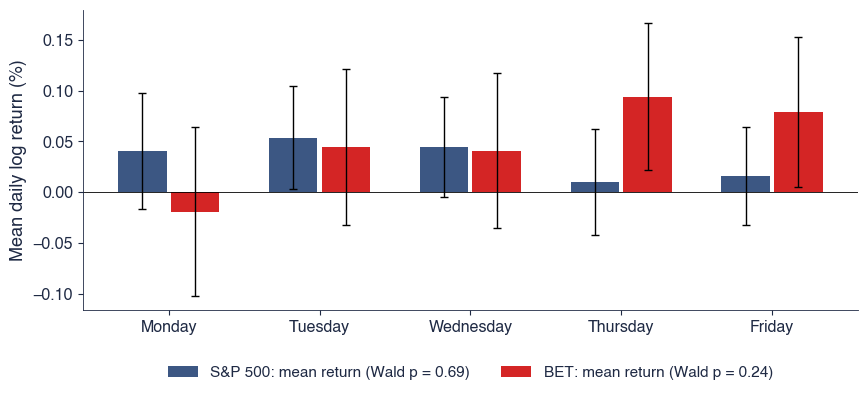

In [30]:
cal = fig_calendar(save=False)
{k: {c: v[c] for c in ['wald_p', 'jan_mean', 'other_mean', 'jan_t', 'jan_p']} for k, v in cal.items()}

## 9. AI for scientific discovery: has the BET become more efficient?

- Open question: did the BET become more efficient after Romania's upgrade to Secondary Emerging market (FTSE Russell, September 2020)?
- Starter result: VR(5) and $Z^*(5)$ in the five years before and after 21 September 2020.
- Check before trusting any answer, yours or an AI's: robust $Z^*$, not $Z$; overlapping windows are not independent tests; the event date is fixed in advance; other changes happened at the same time.

In [31]:
def bet_upgrade(edge=FTSE_UPGRADE, years=5, q=5):
    """The BET in the five years before and after its upgrade to Secondary Emerging market (September 2020)."""
    r = returns('bet')
    e = pd.Timestamp(edge)
    out = {}
    for lab, a, b in [('before', e - pd.DateOffset(years=years), e - pd.Timedelta(days=1)), ('after', e, e + pd.DateOffset(years=years))]:
        x = r.loc[a:b].values
        v = variance_ratio(x, q)
        out[lab] = {'from': r.loc[a:b].index[0].date().isoformat(), 'to': r.loc[a:b].index[-1].date().isoformat(), 'n': len(x),
                    'rho1': float(acf(x, 1)[0]), 'vr': v['vr'], 'zs': v['zs'], 'se': v['se_rob'], 'cd_p': chow_denning(x)['p']}
    out['z_diff'] = (out['after']['vr'] - out['before']['vr']) / np.sqrt(out['after']['se'] ** 2 + out['before']['se'] ** 2)
    return out

In [32]:
up = bet_upgrade()
print('z of the difference:', round(up['z_diff'], 2))
pd.DataFrame({p: up[p] for p in ['before', 'after']}).T

z of the difference: 0.34


,from,to,n,rho1,vr,zs,se,cd_p
before,2015-09-21,2020-09-18,1249,-0.0019,1.122256,0.799465,0.152923,0.781196
after,2020-09-21,2025-09-19,1248,0.087049,1.184312,1.776953,0.103724,0.240167
